

Step 1: Mount Google Drive


In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
PROJECT = "/content/drive/MyDrive/dataset-quality-analyzer"
os.makedirs(f"{PROJECT}/data", exist_ok=True)

Mounted at /content/drive


Step 2: Run your diabetes cell with the right path

In [2]:
import pandas as pd

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
cols = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
        "Insulin", "BMI", "DiabetesPedigreeFunction", "Age", "Outcome"]

df = pd.read_csv(url, header=None, names=cols)
df.to_csv(f"{PROJECT}/data/diabetes.csv", index=False)
print(df.shape)  # (768, 9)

(768, 9)


Unzip them

In [3]:
import zipfile, glob

data_dir = f"{PROJECT}/data"

for z in glob.glob(f"{data_dir}/*.zip"):
    name = os.path.basename(z).replace(".zip", "")
    with zipfile.ZipFile(z) as f:
        f.extractall(f"{data_dir}/{name}")
    print("Extracted:", name)

Extracted: archive
Extracted: heart+disease
Extracted: wine+quality
Extracted: adult
Extracted: archive (1)


See what's inside

In [4]:
for root, dirs, files in os.walk(data_dir):
    for file in files:
        print(os.path.join(root, file).replace(data_dir, ""))

/diabetes.csv
/archive.zip
/heart+disease.zip
/wine+quality.zip
/adult.zip
/archive (1).zip
/archive/WA_Fn-UseC_-Telco-Customer-Churn.csv
/heart+disease/Index
/heart+disease/WARNING
/heart+disease/ask-detrano
/heart+disease/bak
/heart+disease/cleve.mod
/heart+disease/cleveland.data
/heart+disease/heart-disease.names
/heart+disease/hungarian.data
/heart+disease/long-beach-va.data
/heart+disease/new.data
/heart+disease/processed.cleveland.data
/heart+disease/processed.hungarian.data
/heart+disease/processed.switzerland.data
/heart+disease/processed.va.data
/heart+disease/reprocessed.hungarian.data
/heart+disease/switzerland.data
/heart+disease/costs/Index
/heart+disease/costs/heart-disease.README
/heart+disease/costs/heart-disease.cost
/heart+disease/costs/heart-disease.delay
/heart+disease/costs/heart-disease.expense
/heart+disease/costs/heart-disease.group
/wine+quality/winequality-red.csv
/wine+quality/winequality-white.csv
/wine+quality/winequality.names
/adult/Index
/adult/adult.dat

Convert everything into one datasets/ folder

In [5]:
import pandas as pd, os

RAW = f"{PROJECT}/data"
OUT = f"{PROJECT}/datasets"
os.makedirs(OUT, exist_ok=True)

# 1. Diabetes (already done, just copy)
pd.read_csv(f"{RAW}/diabetes.csv").to_csv(f"{OUT}/diabetes.csv", index=False)

# 2. Telco churn
pd.read_csv(f"{RAW}/archive/WA_Fn-UseC_-Telco-Customer-Churn.csv") \
  .to_csv(f"{OUT}/telco_churn.csv", index=False)

# 3. Credit card fraud (big file, may take a moment)
pd.read_csv(f"{RAW}/archive (1)/creditcard.csv") \
  .to_csv(f"{OUT}/creditcard.csv", index=False)

# 4. Wine quality (separator is ;)
pd.read_csv(f"{RAW}/wine+quality/winequality-red.csv", sep=";") \
  .to_csv(f"{OUT}/wine_red.csv", index=False)
pd.read_csv(f"{RAW}/wine+quality/winequality-white.csv", sep=";") \
  .to_csv(f"{OUT}/wine_white.csv", index=False)

# 5. Adult income (no header, "?" means missing)
adult_cols = ["age","workclass","fnlwgt","education","education_num",
              "marital_status","occupation","relationship","race","sex",
              "capital_gain","capital_loss","hours_per_week",
              "native_country","income"]
adult = pd.read_csv(f"{RAW}/adult/adult.data", header=None, names=adult_cols,
                    skipinitialspace=True, na_values="?")
adult.to_csv(f"{OUT}/adult.csv", index=False)

# 6. Heart disease (Cleveland, no header, "?" means missing)
heart_cols = ["age","sex","cp","trestbps","chol","fbs","restecg","thalach",
              "exang","oldpeak","slope","ca","thal","target"]
heart = pd.read_csv(f"{RAW}/heart+disease/processed.cleveland.data",
                    header=None, names=heart_cols, na_values="?")
heart.to_csv(f"{OUT}/heart_disease.csv", index=False)

# 7. Seaborn datasets from earlier
base = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/"
for name in ["titanic", "penguins", "iris", "diamonds", "tips"]:
    pd.read_csv(base + name + ".csv").to_csv(f"{OUT}/{name}.csv", index=False)

print("Done!")

Done!


Check that all of them load

In [6]:
for f in sorted(os.listdir(OUT)):
    d = pd.read_csv(f"{OUT}/{f}")
    print(f"{f:22} rows={d.shape[0]:>7}  cols={d.shape[1]:>3}  missing={d.isnull().sum().sum()}")

adult.csv              rows=  32561  cols= 15  missing=4262
creditcard.csv         rows= 284807  cols= 31  missing=0
diabetes.csv           rows=    768  cols=  9  missing=0
diamonds.csv           rows=  53940  cols= 10  missing=0
heart_disease.csv      rows=    303  cols= 14  missing=6
iris.csv               rows=    150  cols=  5  missing=0
penguins.csv           rows=    344  cols=  7  missing=19
telco_churn.csv        rows=   7043  cols= 21  missing=0
tips.csv               rows=    244  cols=  7  missing=0
titanic.csv            rows=    891  cols= 15  missing=869
wine_red.csv           rows=   1599  cols= 12  missing=0
wine_white.csv         rows=   4898  cols= 12  missing=0


Create checks.py

In [7]:
%%writefile {PROJECT}/checks.py
import pandas as pd

PLACEHOLDERS = {"", "?", "na", "n/a", "nan", "null", "none", "-"}

def check_missing(df):
    n_rows = len(df)
    columns = {}

    for col in df.columns:
        real = int(df[col].isnull().sum())
        hidden = 0
        if not pd.api.types.is_numeric_dtype(df[col]):
            s = df[col].dropna().astype(str).str.strip().str.lower()
            hidden = int(s.isin(PLACEHOLDERS).sum())

        if real + hidden > 0:
            columns[col] = {
                "missing": real,
                "hidden_missing": hidden,
                "percent": round(100 * (real + hidden) / n_rows, 2),
            }

    total = sum(c["missing"] + c["hidden_missing"] for c in columns.values())
    return {
        "total_missing": total,
        "percent_of_cells": round(100 * total / df.size, 2),
        "columns_affected": len(columns),
        "columns": columns,
    }


def check_duplicates(df):
    mask = df.duplicated(keep="first")
    n = int(mask.sum())
    return {
        "duplicate_rows": n,
        "percent": round(100 * n / len(df), 2),
        "example_indices": df.index[mask][:5].tolist(),
    }

Writing /content/drive/MyDrive/dataset-quality-analyzer/checks.py


Test it on all 12 datasets

In [8]:
import sys, importlib
sys.path.append(PROJECT)
import checks
importlib.reload(checks)

for f in sorted(os.listdir(OUT)):
    d = pd.read_csv(f"{OUT}/{f}")
    m = checks.check_missing(d)
    dup = checks.check_duplicates(d)
    print(f"{f:20} missing={m['total_missing']:>5} ({m['percent_of_cells']}%)  "
          f"duplicates={dup['duplicate_rows']:>5} ({dup['percent']}%)")

adult.csv            missing= 4262 (0.87%)  duplicates=   24 (0.07%)
creditcard.csv       missing=    0 (0.0%)  duplicates= 1081 (0.38%)
diabetes.csv         missing=    0 (0.0%)  duplicates=    0 (0.0%)
diamonds.csv         missing=    0 (0.0%)  duplicates=  146 (0.27%)
heart_disease.csv    missing=    6 (0.14%)  duplicates=    0 (0.0%)
iris.csv             missing=    0 (0.0%)  duplicates=    1 (0.67%)
penguins.csv         missing=   19 (0.79%)  duplicates=    0 (0.0%)
telco_churn.csv      missing=   11 (0.01%)  duplicates=    0 (0.0%)
tips.csv             missing=    0 (0.0%)  duplicates=    1 (0.41%)
titanic.csv          missing=  869 (6.5%)  duplicates=  107 (12.01%)
wine_red.csv         missing=    0 (0.0%)  duplicates=  240 (15.01%)
wine_white.csv       missing=    0 (0.0%)  duplicates=  937 (19.13%)


Then look at the detail for Telco:

In [9]:
telco = pd.read_csv(f"{OUT}/telco_churn.csv")
print(checks.check_missing(telco))

{'total_missing': 11, 'percent_of_cells': 0.01, 'columns_affected': 1, 'columns': {'TotalCharges': {'missing': 0, 'hidden_missing': 11, 'percent': 0.16}}}


Add outliers and suspicious zeros

In [10]:
%%writefile -a {PROJECT}/checks.py


def check_outliers(df, factor=1.5):
    """IQR method: flag values outside [Q1 - 1.5*IQR, Q3 + 1.5*IQR]."""
    columns = {}
    for col in df.select_dtypes(include="number").columns:
        s = df[col].dropna()
        if s.nunique() <= 2:          # skip binary columns
            continue
        q1, q3 = s.quantile(0.25), s.quantile(0.75)
        iqr = q3 - q1
        if iqr == 0:                  # no spread, IQR can't work
            continue
        low, high = q1 - factor * iqr, q3 + factor * iqr
        n = int(((s < low) | (s > high)).sum())
        if n > 0:
            columns[col] = {
                "outliers": n,
                "percent": round(100 * n / len(s), 2),
                "lower_bound": round(float(low), 3),
                "upper_bound": round(float(high), 3),
            }
    return {"columns_affected": len(columns), "columns": columns}


def check_suspicious_zeros(df):
    """Zeros in continuous columns that may really mean 'missing'."""
    columns = {}
    for col in df.select_dtypes(include="number").columns:
        s = df[col].dropna()
        if s.nunique() <= 20:         # skip counts/categories (e.g. Pregnancies)
            continue
        zeros = int((s == 0).sum())
        pct = 100 * zeros / len(s)
        nonzero = s[s != 0]
        if zeros > 0 and pct < 60 and nonzero.min() > 0:
            columns[col] = {"zeros": zeros, "percent": round(pct, 2)}
    return {"columns_affected": len(columns), "columns": columns}

Appending to /content/drive/MyDrive/dataset-quality-analyzer/checks.py


Test them

In [11]:
importlib.reload(checks)

for f in sorted(os.listdir(OUT)):
    d = pd.read_csv(f"{OUT}/{f}")
    o = checks.check_outliers(d)
    z = checks.check_suspicious_zeros(d)
    print(f"{f:20} outlier_cols={o['columns_affected']:>2}  "
          f"suspicious_zero_cols={list(z['columns'].keys())}")

# Detail for diabetes
d = pd.read_csv(f"{OUT}/diabetes.csv")
print(checks.check_suspicious_zeros(d))

adult.csv            outlier_cols= 4  suspicious_zero_cols=[]
creditcard.csv       outlier_cols=29  suspicious_zero_cols=['Time', 'Amount']
diabetes.csv         outlier_cols= 8  suspicious_zero_cols=['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
diamonds.csv         outlier_cols= 7  suspicious_zero_cols=['x', 'y', 'z']
heart_disease.csv    outlier_cols= 6  suspicious_zero_cols=['oldpeak']
iris.csv             outlier_cols= 1  suspicious_zero_cols=[]
penguins.csv         outlier_cols= 0  suspicious_zero_cols=[]
telco_churn.csv      outlier_cols= 0  suspicious_zero_cols=['tenure']
tips.csv             outlier_cols= 3  suspicious_zero_cols=[]
titanic.csv          outlier_cols= 3  suspicious_zero_cols=['fare']
wine_red.csv         outlier_cols=12  suspicious_zero_cols=['citric acid']
wine_white.csv       outlier_cols=11  suspicious_zero_cols=['citric acid']
{'columns_affected': 5, 'columns': {'Glucose': {'zeros': 5, 'percent': 0.65}, 'BloodPressure': {'zeros': 35, 'percent

: Add the last three checks

In [12]:
%%writefile -a {PROJECT}/checks.py


def check_constant(df, near_threshold=0.99):
    """Constant, near-constant, and ID-like columns (useless for modelling)."""
    constant, near_constant, id_like = [], {}, []
    for col in df.columns:
        s = df[col].dropna()
        if len(s) == 0 or s.nunique() <= 1:
            constant.append(col)
            continue
        top_share = s.value_counts(normalize=True).iloc[0]
        if top_share >= near_threshold:
            near_constant[col] = round(100 * float(top_share), 2)
        # ID-like: every value unique in a text or integer column
        is_text = not pd.api.types.is_numeric_dtype(s)
        is_int = pd.api.types.is_integer_dtype(s)
        if s.nunique() == len(s) and (is_text or is_int) and len(s) > 20:
            id_like.append(col)
    return {"constant": constant, "near_constant": near_constant, "id_like": id_like}


def check_correlation(df, threshold=0.9):
    """Pairs of numeric columns with |correlation| >= threshold."""
    num = df.select_dtypes(include="number")
    if num.shape[1] < 2:
        return {"pairs": []}
    corr = num.corr().abs()
    pairs = []
    cols = corr.columns
    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):
            v = corr.iloc[i, j]
            if pd.notna(v) and v >= threshold:
                pairs.append({"col_a": cols[i], "col_b": cols[j],
                              "correlation": round(float(v), 3)})
    pairs.sort(key=lambda p: -p["correlation"])
    return {"pairs": pairs}


def guess_target(df):
    """Guess the target column: last column if it looks like a class label."""
    last = df.columns[-1]
    if df[last].nunique() <= 10:
        return last
    return None


def check_imbalance(df, target=None):
    target = target or guess_target(df)
    if target is None or target not in df.columns:
        return {"target": None, "note": "no class column detected"}
    counts = df[target].value_counts()
    ratio = float(counts.iloc[0] / counts.iloc[-1])
    if ratio < 1.5:
        severity = "balanced"
    elif ratio < 3:
        severity = "mild"
    elif ratio < 10:
        severity = "moderate"
    else:
        severity = "severe"
    return {
        "target": target,
        "classes": {str(k): int(v) for k, v in counts.items()},
        "majority_minority_ratio": round(ratio, 2),
        "minority_percent": round(100 * float(counts.iloc[-1] / counts.sum()), 2),
        "severity": severity,
    }

Appending to /content/drive/MyDrive/dataset-quality-analyzer/checks.py


Test all three

In [13]:
importlib.reload(checks)

for f in sorted(os.listdir(OUT)):
    d = pd.read_csv(f"{OUT}/{f}")
    c = checks.check_constant(d)
    r = checks.check_correlation(d)
    i = checks.check_imbalance(d)
    print(f"{f:20} target={str(i['target']):12} "
          f"imbalance={i.get('severity','-'):9} ratio={i.get('majority_minority_ratio','-')}")
    print(f"{'':20} constant={c['constant']} near={list(c['near_constant'])} id_like={c['id_like']}")
    print(f"{'':20} correlated_pairs={[(p['col_a'], p['col_b'], p['correlation']) for p in r['pairs']]}")

adult.csv            target=income       imbalance=moderate  ratio=3.15
                     constant=[] near=[] id_like=[]
                     correlated_pairs=[]
creditcard.csv       target=Class        imbalance=severe    ratio=577.88
                     constant=[] near=['Class'] id_like=[]
                     correlated_pairs=[]
diabetes.csv         target=Outcome      imbalance=mild      ratio=1.87
                     constant=[] near=[] id_like=[]
                     correlated_pairs=[]
diamonds.csv         target=None         imbalance=-         ratio=-
                     constant=[] near=[] id_like=[]
                     correlated_pairs=[('carat', 'x', 0.975), ('x', 'y', 0.975), ('x', 'z', 0.971), ('carat', 'z', 0.953), ('carat', 'y', 0.952), ('y', 'z', 0.952), ('carat', 'price', 0.922)]
heart_disease.csv    target=target       imbalance=severe    ratio=12.62
                     constant=[] near=[] id_like=[]
                     correlated_pairs=[]
iris.csv         

One analyze() function with a quality score

In [14]:
%%writefile {PROJECT}/analyzer.py
import checks

def _grade(score):
    for cutoff, g in [(90, "A"), (75, "B"), (60, "C"), (40, "D")]:
        if score >= cutoff:
            return g
    return "F"

def analyze(df, target=None):
    target = target or checks.guess_target(df)
    n_num = max(1, df.select_dtypes(include="number").shape[1])

    missing  = checks.check_missing(df)
    dups     = checks.check_duplicates(df)
    outliers = checks.check_outliers(df)
    zeros    = checks.check_suspicious_zeros(df)
    const    = checks.check_constant(df)
    corr     = checks.check_correlation(df)
    imb      = checks.check_imbalance(df, target)

    # the target's imbalance is reported separately, not as a "useless column"
    const["near_constant"].pop(target, None)

    # ---- penalties (each capped, total max = 100) ----
    mean_out = sum(c["percent"] for c in outliers["columns"].values()) / n_num
    sev = {"balanced": 0, "mild": 3, "moderate": 8, "severe": 15}
    penalties = {
        "missing":          min(25, missing["percent_of_cells"] * 5),
        "duplicates":       min(15, dups["percent"] * 0.75),
        "outliers":         min(15, mean_out * 3),
        "suspicious_zeros": min(10, 10 * zeros["columns_affected"] / n_num),
        "imbalance":        sev.get(imb.get("severity"), 0),
        "useless_columns":  min(10, 5 * len(const["constant"])
                                   + 3 * len(const["near_constant"])
                                   + 2 * len(const["id_like"])),
        "correlation":      min(10, 2 * len(corr["pairs"])),
    }
    score = round(100 - sum(penalties.values()), 1)

    # ---- human-readable issues ("review", never "remove") ----
    issues = []
    if missing["total_missing"]:
        issues.append(f"Missing values in {missing['columns_affected']} column(s) "
                      f"({missing['percent_of_cells']}% of cells).")
    if dups["duplicate_rows"]:
        issues.append(f"{dups['duplicate_rows']} duplicate rows ({dups['percent']}%). "
                      "Please review: repeated rows can be legitimate.")
    if outliers["columns_affected"]:
        issues.append(f"Statistical outliers in {outliers['columns_affected']} column(s). "
                      "Please review before removing.")
    if zeros["columns_affected"]:
        issues.append("Suspicious zeros (possibly hidden missing values) in: "
                      + ", ".join(zeros["columns"]) + ".")
    if imb.get("severity") in ("moderate", "severe"):
        issues.append(f"Class imbalance in '{imb['target']}' is {imb['severity']} "
                      f"(ratio {imb['majority_minority_ratio']}:1).")
    if const["constant"] or const["near_constant"] or const["id_like"]:
        issues.append("Low-value columns: "
                      + ", ".join(const["constant"] + list(const["near_constant"]) + const["id_like"]) + ".")
    if corr["pairs"]:
        issues.append(f"{len(corr['pairs'])} highly correlated feature pair(s).")

    return {
        "shape": {"rows": int(df.shape[0]), "columns": int(df.shape[1])},
        "target": target,
        "score": score,
        "grade": _grade(score),
        "penalties": {k: round(v, 1) for k, v in penalties.items()},
        "issues": issues,
        "details": {"missing": missing, "duplicates": dups, "outliers": outliers,
                    "suspicious_zeros": zeros, "constant": const,
                    "correlation": corr, "imbalance": imb},
    }

Writing /content/drive/MyDrive/dataset-quality-analyzer/analyzer.py


Test it

In [15]:
import json, importlib
importlib.reload(checks)
import analyzer
importlib.reload(analyzer)

for f in sorted(os.listdir(OUT)):
    d = pd.read_csv(f"{OUT}/{f}")
    r = analyzer.analyze(d)
    json.dumps(r)   # must not crash: Flask needs JSON-safe output
    worst = max(r["penalties"], key=r["penalties"].get)
    print(f"{f:20} score={r['score']:>5}  grade={r['grade']}  biggest_penalty={worst}")

# Full report for one dataset
r = analyzer.analyze(pd.read_csv(f"{OUT}/diabetes.csv"))
print(r["score"], r["penalties"])
for i in r["issues"]:
    print("-", i)

adult.csv            score= 72.6  grade=C  biggest_penalty=outliers
creditcard.csv       score= 71.5  grade=C  biggest_penalty=imbalance
diabetes.csv         score= 85.1  grade=B  biggest_penalty=outliers
diamonds.csv         score= 78.6  grade=B  biggest_penalty=correlation
heart_disease.csv    score= 79.1  grade=B  biggest_penalty=imbalance
iris.csv             score= 95.5  grade=A  biggest_penalty=outliers
penguins.csv         score= 96.0  grade=A  biggest_penalty=missing
telco_churn.csv      score= 91.6  grade=A  biggest_penalty=suspicious_zeros
tips.csv             score= 73.6  grade=C  biggest_penalty=imbalance
titanic.csv          score= 51.5  grade=D  biggest_penalty=missing
wine_red.csv         score= 63.5  grade=C  biggest_penalty=imbalance
wine_white.csv       score= 63.4  grade=C  biggest_penalty=imbalance
85.1 {'missing': 0.0, 'duplicates': 0.0, 'outliers': 6.3, 'suspicious_zeros': 5.6, 'imbalance': 3, 'useless_columns': 0, 'correlation': 0}
- Statistical outliers in 8 col

Patch: severity-based zeros penalty

In [16]:
p = f"{PROJECT}/analyzer.py"
src = open(p).read()
old = '"suspicious_zeros": min(10, 10 * zeros["columns_affected"] / n_num),'
new = '"suspicious_zeros": min(10, sum(c["percent"] for c in zeros["columns"].values()) / 5),'
assert old in src, "line not found, check analyzer.py"
open(p, "w").write(src.replace(old, new))

3450

cleaner.py

In [17]:
%%writefile {PROJECT}/cleaner.py
import numpy as np
import pandas as pd
import checks


def _placeholders_to_nan(s):
    txt = s.astype(str).str.strip().str.lower()
    return s.where(~txt.isin(checks.PLACEHOLDERS) & s.notna())


def _drop_correlated(df, target, threshold):
    """Greedy: drop the weaker column of the most correlated pair, repeat."""
    dropped = []
    target_numeric = target in df.columns and pd.api.types.is_numeric_dtype(df[target])
    while True:
        num = df.select_dtypes(include="number").drop(columns=[target], errors="ignore")
        if num.shape[1] < 2:
            break
        corr = num.corr().abs().fillna(0)
        corr = corr.where(~np.eye(len(corr), dtype=bool), 0)
        a, b = corr.stack().idxmax()
        if corr.loc[a, b] < threshold:
            break
        if target_numeric:
            # keep the column more related to the target
            drop = b if abs(df[a].corr(df[target])) >= abs(df[b].corr(df[target])) else a
        else:
            # keep the less redundant column
            drop = a if corr[a].mean() >= corr[b].mean() else b
        dropped.append((drop, a if drop == b else b, round(float(corr.loc[a, b]), 3)))
        df = df.drop(columns=[drop])
    return df, dropped


def clean(df, target=None, zero_cols=(), drop_duplicates=False,
          cap_outliers=False, corr_threshold=0.9, max_missing_pct=60):
    df = df.copy()
    log = []

    # 1. hidden missing values and numbers stored as text
    for col in df.select_dtypes(exclude="number").columns:
        s = _placeholders_to_nan(df[col])
        hidden = int(s.isna().sum() - df[col].isna().sum())
        num = pd.to_numeric(s, errors="coerce")
        if s.notna().sum() and num.notna().sum() / s.notna().sum() >= 0.95:
            df[col] = num
            log.append(f"'{col}': converted text to numeric ({hidden} hidden missing -> NaN)")
        elif hidden:
            df[col] = s
            log.append(f"'{col}': {hidden} placeholder values -> NaN")

    # 2. suspicious zeros, only for columns the user confirmed
    for col in zero_cols:
        n = int((df[col] == 0).sum())
        df[col] = df[col].replace(0, np.nan)
        log.append(f"'{col}': {n} zeros treated as missing")

    # 3. duplicates (opt-in)
    if drop_duplicates:
        n = int(df.duplicated().sum())
        df = df.drop_duplicates()
        log.append(f"Dropped {n} duplicate rows")

    # 4. useless columns (never the target)
    const = checks.check_constant(df)
    useless = (set(const["constant"]) | set(const["near_constant"]) | set(const["id_like"])) - {target}
    if useless:
        df = df.drop(columns=sorted(useless))
        log.append(f"Dropped useless columns: {sorted(useless)}")

    # 5. columns that are mostly empty
    pct = df.isna().mean() * 100
    too_empty = [c for c in df.columns if pct[c] > max_missing_pct and c != target]
    if too_empty:
        df = df.drop(columns=too_empty)
        log.append(f"Dropped columns with >{max_missing_pct}% missing: {too_empty}")

    # 6. impute (rows with a missing target are dropped, never imputed)
    if target in df.columns and df[target].isna().any():
        n = int(df[target].isna().sum())
        df = df.dropna(subset=[target])
        log.append(f"Dropped {n} rows with missing target")
    for col in df.columns:
        if col == target or not df[col].isna().any():
            continue
        n = int(df[col].isna().sum())
        if pd.api.types.is_numeric_dtype(df[col]):
            df[col] = df[col].fillna(df[col].median())
            log.append(f"'{col}': {n} missing -> median")
        else:
            df[col] = df[col].fillna(df[col].mode().iloc[0])
            log.append(f"'{col}': {n} missing -> most frequent value")

    # 7. cap outliers (opt-in)
    if cap_outliers:
        for col in df.select_dtypes(include="number").columns:
            if col == target or df[col].nunique() <= 2:
                continue
            q1, q3 = df[col].quantile([0.25, 0.75])
            iqr = q3 - q1
            if iqr == 0:
                continue
            lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
            n = int(((df[col] < lo) | (df[col] > hi)).sum())
            if n:
                df[col] = df[col].clip(lo, hi)
                log.append(f"'{col}': {n} outliers capped to [{lo:.2f}, {hi:.2f}]")

    # 8. correlated features
    df, dropped = _drop_correlated(df, target, corr_threshold)
    for drop, keep, c in dropped:
        log.append(f"Dropped '{drop}' (correlation {c} with '{keep}')")

    return df, log

Writing /content/drive/MyDrive/dataset-quality-analyzer/cleaner.py


Test with before/after scores

In [18]:
import importlib, cleaner
importlib.reload(checks); importlib.reload(analyzer); importlib.reload(cleaner)

tests = {
    "telco_churn.csv": ("Churn", []),
    "diamonds.csv":    ("price", []),
    "diabetes.csv":    ("Outcome", ["Glucose","BloodPressure","SkinThickness","Insulin","BMI"]),
    "titanic.csv":     ("survived", []),
}

for f, (tgt, zc) in tests.items():
    raw = pd.read_csv(f"{OUT}/{f}")
    cleaned, log = cleaner.clean(raw, target=tgt, zero_cols=zc)
    b = analyzer.analyze(raw, tgt)["score"]
    a = analyzer.analyze(cleaned, tgt)["score"]
    print(f"\n{f}: {raw.shape} -> {cleaned.shape}   score {b} -> {a}")
    for line in log:
        print("  -", line)


telco_churn.csv: (7043, 21) -> (7043, 20)   score 94.9 -> 96.7
  - 'TotalCharges': converted text to numeric (11 hidden missing -> NaN)
  - Dropped useless columns: ['customerID']
  - 'TotalCharges': 11 missing -> median

diamonds.csv: (53940, 10) -> (53940, 7)   score 67.9 -> 70.0
  - Dropped 'x' (correlation 0.975 with 'carat')
  - Dropped 'z' (correlation 0.953 with 'carat')
  - Dropped 'y' (correlation 0.952 with 'carat')

diabetes.csv: (768, 9) -> (768, 9)   score 80.7 -> 82.0
  - 'Glucose': 5 zeros treated as missing
  - 'BloodPressure': 35 zeros treated as missing
  - 'SkinThickness': 227 zeros treated as missing
  - 'Insulin': 374 zeros treated as missing
  - 'BMI': 11 zeros treated as missing
  - 'Glucose': 5 missing -> median
  - 'BloodPressure': 35 missing -> median
  - 'SkinThickness': 227 missing -> median
  - 'Insulin': 374 missing -> median
  - 'BMI': 11 missing -> median

titanic.csv: (891, 15) -> (891, 14)   score 52.8 -> 74.1
  - 'adult_male': converted text to numer

Patches

In [19]:
# Patch 1: skip boolean columns in the cleaner
p = f"{PROJECT}/cleaner.py"
src = open(p).read()
old = '    for col in df.select_dtypes(exclude="number").columns:\n        s = _placeholders_to_nan(df[col])'
new = ('    for col in df.select_dtypes(exclude="number").columns:\n'
       '        if pd.api.types.is_bool_dtype(df[col]):\n'
       '            continue\n'
       '        s = _placeholders_to_nan(df[col])')
assert old in src, "cleaner.py text not found"
open(p, "w").write(src.replace(old, new))

# Patch 2: exclude the target from the correlation penalty
p = f"{PROJECT}/analyzer.py"
src = open(p).read()
old = '    corr     = checks.check_correlation(df)\n'
new = old + '    corr["pairs"] = [q for q in corr["pairs"] if target not in (q["col_a"], q["col_b"])]\n'
assert old in src, "analyzer.py text not found"
open(p, "w").write(src.replace(old, new))

3539

Verify the diabetes hypothesis

In [20]:
importlib.reload(checks); importlib.reload(cleaner); importlib.reload(analyzer)

zc = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
raw = pd.read_csv(f"{OUT}/diabetes.csv")
cleaned, _ = cleaner.clean(raw, target="Outcome", zero_cols=zc)

for name, d in [("before", raw), ("after", cleaned)]:
    r = analyzer.analyze(d, "Outcome")
    print(name, r["score"], r["penalties"])
    print("  outlier % per column:",
          {c: v["percent"] for c, v in r["details"]["outliers"]["columns"].items()})

before 80.7 {'missing': 0.0, 'duplicates': 0.0, 'outliers': 6.3, 'suspicious_zeros': 10, 'imbalance': 3, 'useless_columns': 0, 'correlation': 0}
  outlier % per column: {'Pregnancies': 0.52, 'Glucose': 0.65, 'BloodPressure': 5.86, 'SkinThickness': 0.13, 'Insulin': 4.43, 'BMI': 2.47, 'DiabetesPedigreeFunction': 3.78, 'Age': 1.17}
after 82.0 {'missing': 0.0, 'duplicates': 0.0, 'outliers': 15, 'suspicious_zeros': 0.0, 'imbalance': 3, 'useless_columns': 0, 'correlation': 0}
  outlier % per column: {'Pregnancies': 0.52, 'BloodPressure': 1.82, 'SkinThickness': 11.33, 'Insulin': 45.05, 'BMI': 1.04, 'DiabetesPedigreeFunction': 3.78, 'Age': 1.17}


Unit tests (pytest)

In [21]:
os.makedirs(f"{PROJECT}/tests", exist_ok=True)

In [22]:
%%writefile {PROJECT}/tests/test_project.py
import json
import sys
from pathlib import Path

sys.path.insert(0, str(Path(__file__).resolve().parents[1]))

import numpy as np
import pandas as pd
import analyzer
import checks
import cleaner


def test_missing_detects_real_and_hidden():
    df = pd.DataFrame({"a": [1, None, 3, 4], "b": ["x", " ", "?", "y"]})
    r = checks.check_missing(df)
    assert r["columns"]["a"]["missing"] == 1
    assert r["columns"]["b"]["hidden_missing"] == 2
    assert r["total_missing"] == 3


def test_duplicates():
    df = pd.DataFrame({"a": [1, 1, 2], "b": [5, 5, 6]})
    assert checks.check_duplicates(df)["duplicate_rows"] == 1


def test_outliers_flags_extreme_value():
    df = pd.DataFrame({"a": [10, 11, 12, 11, 10, 12, 11, 500]})
    assert checks.check_outliers(df)["columns"]["a"]["outliers"] == 1


def test_constant_and_id_columns():
    df = pd.DataFrame({"const": [1] * 30, "id": range(30),
                       "x": [i % 3 for i in range(30)]})
    r = checks.check_constant(df)
    assert r["constant"] == ["const"]
    assert r["id_like"] == ["id"]


def test_correlation_pair():
    x = np.arange(50)
    df = pd.DataFrame({"a": x, "b": x * 2 + 1,
                       "c": np.random.RandomState(0).rand(50)})
    pairs = checks.check_correlation(df)["pairs"]
    assert len(pairs) == 1
    assert {pairs[0]["col_a"], pairs[0]["col_b"]} == {"a", "b"}


def test_imbalance_severity():
    df = pd.DataFrame({"f": range(100), "y": [0] * 95 + [1] * 5})
    r = checks.check_imbalance(df, "y")
    assert r["severity"] == "severe"
    assert r["majority_minority_ratio"] == 19.0


def test_cleaner_converts_text_numbers_and_imputes():
    df = pd.DataFrame({"v": ["1", "2", " ", "4"] * 10, "y": [0, 1] * 20})
    cleaned, _ = cleaner.clean(df, target="y")
    assert pd.api.types.is_numeric_dtype(cleaned["v"])
    assert cleaned["v"].isna().sum() == 0


def test_cleaner_never_drops_target():
    df = pd.DataFrame({"a": range(30), "y": [1] * 30})
    cleaned, _ = cleaner.clean(df, target="y")
    assert "y" in cleaned.columns


def test_cleaner_does_not_modify_input():
    df = pd.DataFrame({"a": [1, None, 3] * 10, "y": [0, 1, 0] * 10})
    before = df.copy()
    cleaner.clean(df, target="y")
    pd.testing.assert_frame_equal(df, before)


def test_bool_columns_left_alone():
    # regression test for the false "converted text to numeric" log message
    df = pd.DataFrame({"flag": [True, False] * 15, "y": [0, 1] * 15})
    _, log = cleaner.clean(df, target="y")
    assert not any("flag" in line and "converted" in line for line in log)


def test_analyze_is_json_safe_and_bounded():
    df = pd.DataFrame({"a": np.random.RandomState(1).rand(60), "y": [0, 1] * 30})
    r = analyzer.analyze(df, "y")
    json.dumps(r)
    assert 0 <= r["score"] <= 100

Writing /content/drive/MyDrive/dataset-quality-analyzer/tests/test_project.py


In [23]:
!pip install -q pytest
!cd {PROJECT} && python -m pytest tests -q

...........                                                              [100%]
11 passed in 0.71s


heavy-imputation warnings + optional KNN imputer

In [24]:
def patch(path, old, new):
    src = open(path).read()
    assert src.count(old) == 1, f"expected exactly 1 match, found {src.count(old)}"
    open(path, "w").write(src.replace(old, new))

p = f"{PROJECT}/cleaner.py"

# 1. imports
patch(p, "import checks\n",
      "import checks\nfrom sklearn.impute import KNNImputer\nfrom sklearn.preprocessing import StandardScaler\n")

# 2. helper function
patch(p, "def clean(df, target=None, zero_cols=(), drop_duplicates=False,\n"
         "          cap_outliers=False, corr_threshold=0.9, max_missing_pct=60):",
'''def _knn_impute(df, cols, k=5):
    """Scale, impute from the k most similar rows, then unscale."""
    scaler = StandardScaler()
    X = KNNImputer(n_neighbors=k).fit_transform(scaler.fit_transform(df[cols]))
    out = df.copy()
    out[cols] = scaler.inverse_transform(X)
    return out


def clean(df, target=None, zero_cols=(), drop_duplicates=False,
          cap_outliers=False, corr_threshold=0.9, max_missing_pct=60,
          imputer="median", warn_missing_pct=30):''')

# 3. imputation step
patch(p, '''    for col in df.columns:
        if col == target or not df[col].isna().any():
            continue
        n = int(df[col].isna().sum())
        if pd.api.types.is_numeric_dtype(df[col]):
            df[col] = df[col].fillna(df[col].median())
            log.append(f"'{col}': {n} missing -> median")
        else:
            df[col] = df[col].fillna(df[col].mode().iloc[0])
            log.append(f"'{col}': {n} missing -> most frequent value")
''', '''    knn_used = False
    for col in df.columns:
        if col == target or not df[col].isna().any():
            continue
        n = int(df[col].isna().sum())
        share = 100 * n / len(df)
        if share > warn_missing_pct:
            log.append(f"WARNING '{col}': {share:.1f}% missing, imputed values are unreliable")
        if pd.api.types.is_numeric_dtype(df[col]):
            if imputer == "knn":
                knn_used = True
                log.append(f"'{col}': {n} missing -> KNN estimate")
            else:
                df[col] = df[col].fillna(df[col].median())
                log.append(f"'{col}': {n} missing -> median")
        else:
            df[col] = df[col].fillna(df[col].mode().iloc[0])
            log.append(f"'{col}': {n} missing -> most frequent value")
    if knn_used:
        num_cols = [c for c in df.select_dtypes(include="number").columns if c != target]
        df = _knn_impute(df, num_cols)
''')
print("patched")

patched


Add two tests:

In [25]:
%%writefile -a {PROJECT}/tests/test_project.py


def test_heavy_imputation_warns():
    df = pd.DataFrame({"a": [None] * 20 + list(range(20)), "b": range(40),
                       "y": [0, 1] * 20})
    _, log = cleaner.clean(df, target="y")
    assert any(line.startswith("WARNING") and "'a'" in line for line in log)


def test_knn_imputer_fills_everything():
    rs = np.random.RandomState(0)
    df = pd.DataFrame(rs.rand(60, 3), columns=list("abc"))
    df["y"] = [0, 1] * 30
    df.loc[:9, "a"] = np.nan
    cleaned, _ = cleaner.clean(df, target="y", imputer="knn")
    assert cleaned["a"].isna().sum() == 0

Appending to /content/drive/MyDrive/dataset-quality-analyzer/tests/test_project.py


Compare median vs KNN

In [26]:
importlib.reload(cleaner)

for imp in ["median", "knn"]:
    cleaned, log = cleaner.clean(raw, target="Outcome", zero_cols=zc, imputer=imp)
    r = analyzer.analyze(cleaned, "Outcome")
    print(f"\n[{imp}] score={r['score']}  outlier penalty={r['penalties']['outliers']}")
    print("  outlier % per column:",
          {c: v["percent"] for c, v in r["details"]["outliers"]["columns"].items()})
    print("  warnings:", [l for l in log if l.startswith("WARNING")])

!cd {PROJECT} && python -m pytest tests -q


[median] score=82.0  outlier penalty=15
  outlier % per column: {'Pregnancies': 0.52, 'BloodPressure': 1.82, 'SkinThickness': 11.33, 'Insulin': 45.05, 'BMI': 1.04, 'DiabetesPedigreeFunction': 3.78, 'Age': 1.17}
  warnings: ["WARNING 'Insulin': 48.7% missing, imputed values are unreliable"]

[knn] score=92.7  outlier penalty=4.3
  outlier % per column: {'Pregnancies': 0.52, 'BloodPressure': 1.82, 'SkinThickness': 0.78, 'Insulin': 3.65, 'BMI': 1.04, 'DiabetesPedigreeFunction': 3.78, 'Age': 1.17}
  warnings: ["WARNING 'Insulin': 48.7% missing, imputed values are unreliable"]
.............                                                            [100%]
13 passed in 2.38s


In [27]:
def patch(path, old, new):
    src = open(path).read()
    assert src.count(old) == 1, f"expected exactly 1 match, found {src.count(old)}"
    open(path, "w").write(src.replace(old, new))

p = f"{PROJECT}/cleaner.py"
patch(p, 'imputer="median", warn_missing_pct=30):',
         'imputer="median", warn_missing_pct=30, impute=True):')
patch(p, 'if col == target or not df[col].isna().any():',
         'if col == target or not impute or not df[col].isna().any():')
print("patched")

patched


In [28]:
%%writefile -a {PROJECT}/tests/test_project.py


def test_impute_false_keeps_missing():
    df = pd.DataFrame({"a": [1, None, 3] * 10, "y": [0, 1, 0] * 10})
    cleaned, _ = cleaner.clean(df, target="y", impute=False)
    assert cleaned["a"].isna().sum() == 10

Appending to /content/drive/MyDrive/dataset-quality-analyzer/tests/test_project.py


Now the experiment:

In [29]:
import time, warnings
import numpy as np
import pandas as pd
import importlib
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
warnings.filterwarnings("ignore")
importlib.reload(cleaner)

def build_model(X):
    num = X.select_dtypes(include="number").columns.tolist()
    cat = [c for c in X.columns if c not in num]
    pre = ColumnTransformer([
        ("num", SimpleImputer(strategy="median"), num),
        ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                          ("oh", OneHotEncoder(handle_unknown="ignore"))]), cat),
    ])
    return Pipeline([("pre", pre),
                     ("rf", RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))])

def evaluate(X, y, idx_train, idx_test):
    X = X.astype({c: int for c in X.select_dtypes(include="bool").columns})
    Xtr, Xte = X.iloc[idx_train], X.iloc[idx_test]
    ytr, yte = y.iloc[idx_train], y.iloc[idx_test]
    model = build_model(Xtr)
    cv = cross_val_score(model, Xtr, ytr, scoring="accuracy",
                         cv=StratifiedKFold(5, shuffle=True, random_state=42))
    model.fit(Xtr, ytr)
    return {"train": model.score(Xtr, ytr), "val": cv.mean(),
            "val_std": cv.std(), "test": model.score(Xte, yte)}

TASKS = [  # (file, target, columns to drop, columns whose zeros mean "missing")
    ("diabetes.csv", "Outcome", [], ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]),
    ("telco_churn.csv", "Churn", [], []),
    ("titanic.csv", "survived", ["alive"], []),      # 'alive' leaks the target
    ("adult.csv", "income", [], []),
    ("heart_disease.csv", "target", [], []),
    ("penguins.csv", "species", [], []),
]

print("=" * 76)
print("IMPACT TEST STARTED: raw vs cleaned data (same model, same split)")
print("=" * 76)
t0 = time.time()
rows = []

for f, tgt, drop_cols, zc in TASKS:
    print(f"\n[{time.strftime('%H:%M:%S')}] TRAINING STARTED on {f} ...")
    df = pd.read_csv(f"{OUT}/{f}").drop(columns=drop_cols)
    if f == "heart_disease.csv":
        df[tgt] = (df[tgt] > 0).astype(int)            # 0 = healthy, 1 = disease
    df = df.dropna(subset=[tgt]).reset_index(drop=True)
    y = df[tgt]
    itr, ite = train_test_split(np.arange(len(df)), test_size=0.2,
                                stratify=y, random_state=42)

    clean_df, _ = cleaner.clean(df, target=tgt, zero_cols=zc,
                                impute=False, corr_threshold=1.01)
    raw = evaluate(df.drop(columns=[tgt]), y, itr, ite)
    cln = evaluate(clean_df.drop(columns=[tgt]), y, itr, ite)

    for name, r in [("RAW    ", raw), ("CLEANED", cln)]:
        print(f"   {name} train={r['train']:.4f} | validation (5-fold CV)="
              f"{r['val']:.4f} +/-{r['val_std']:.4f} | TEST ACCURACY={r['test']:.4f}")
    rows.append({"dataset": f, "val_raw": raw["val"], "val_clean": cln["val"],
                 "test_raw": raw["test"], "test_clean": cln["test"]})

summary = pd.DataFrame(rows)
summary["val_change_pts"] = (summary.val_clean - summary.val_raw) * 100
summary["test_change_pts"] = (summary.test_clean - summary.test_raw) * 100
print("\n" + "=" * 76)
print("IMPACT TEST FINISHED in", round(time.time() - t0), "seconds. Accuracy summary:")
print(summary.round(4).to_string(index=False))

IMPACT TEST STARTED: raw vs cleaned data (same model, same split)

[15:21:02] TRAINING STARTED on diabetes.csv ...
   RAW     train=1.0000 | validation (5-fold CV)=0.7639 +/-0.0270 | TEST ACCURACY=0.7597
   CLEANED train=1.0000 | validation (5-fold CV)=0.7606 +/-0.0188 | TEST ACCURACY=0.7662

[15:21:08] TRAINING STARTED on telco_churn.csv ...
   RAW     train=1.0000 | validation (5-fold CV)=0.7902 +/-0.0088 | TEST ACCURACY=0.7942
   CLEANED train=0.9980 | validation (5-fold CV)=0.7843 +/-0.0134 | TEST ACCURACY=0.7779

[15:22:00] TRAINING STARTED on titanic.csv ...
   RAW     train=0.9846 | validation (5-fold CV)=0.7978 +/-0.0194 | TEST ACCURACY=0.8156
   CLEANED train=0.9831 | validation (5-fold CV)=0.7992 +/-0.0201 | TEST ACCURACY=0.8268

[15:22:04] TRAINING STARTED on adult.csv ...
   RAW     train=1.0000 | validation (5-fold CV)=0.8524 +/-0.0031 | TEST ACCURACY=0.8569
   CLEANED train=1.0000 | validation (5-fold CV)=0.8524 +/-0.0031 | TEST ACCURACY=0.8569

[15:24:44] TRAINING STARTE

Same test with Logistic Regression + paired folds

In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.preprocessing import StandardScaler

def build_model_lr(X):
    num = X.select_dtypes(include="number").columns.tolist()
    cat = [c for c in X.columns if c not in num]
    pre = ColumnTransformer([
        ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                          ("sc", StandardScaler())]), num),
        ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                          ("oh", OneHotEncoder(handle_unknown="ignore"))]), cat),
    ])
    return Pipeline([("pre", pre), ("lr", LogisticRegression(max_iter=2000))])

def _prep(X):
    return X.astype({c: int for c in X.select_dtypes(include="bool").columns})

def paired_cv(X_raw, X_cln, y, itr, builder):
    cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=42)
    ytr = y.iloc[itr]
    scores = []
    for X in (_prep(X_raw).iloc[itr], _prep(X_cln).iloc[itr]):
        scores.append(cross_val_score(builder(X), X, ytr, cv=cv, scoring="accuracy"))
    return scores

def test_acc(X, y, itr, ite, builder):
    X = _prep(X)
    m = builder(X.iloc[itr]).fit(X.iloc[itr], y.iloc[itr])
    return m.score(X.iloc[ite], y.iloc[ite])

SUBSET = [t for t in TASKS if t[0] in ("diabetes.csv", "telco_churn.csv", "titanic.csv")]

print("=" * 78)
print("LOGISTIC REGRESSION IMPACT TEST STARTED (5-fold x 3 repeats, paired folds)")
print("=" * 78)
for f, tgt, drop_cols, zc in SUBSET:
    print(f"\n[{time.strftime('%H:%M:%S')}] TRAINING STARTED on {f} ...")
    df = pd.read_csv(f"{OUT}/{f}").drop(columns=drop_cols)
    df = df.dropna(subset=[tgt]).reset_index(drop=True)
    y = df[tgt]
    itr, ite = train_test_split(np.arange(len(df)), test_size=0.2,
                                stratify=y, random_state=42)
    clean_df, _ = cleaner.clean(df, target=tgt, zero_cols=zc,
                                impute=False, corr_threshold=1.01)
    X_raw, X_cln = df.drop(columns=[tgt]), clean_df.drop(columns=[tgt])

    a, b = paired_cv(X_raw, X_cln, y, itr, build_model_lr)
    t_raw = test_acc(X_raw, y, itr, ite, build_model_lr)
    t_cln = test_acc(X_cln, y, itr, ite, build_model_lr)

    print(f"   RAW     validation accuracy = {a.mean():.4f} +/-{a.std():.4f} | TEST ACCURACY = {t_raw:.4f}")
    print(f"   CLEANED validation accuracy = {b.mean():.4f} +/-{b.std():.4f} | TEST ACCURACY = {t_cln:.4f}")
    print(f"   Change: {100*(b.mean()-a.mean()):+.2f} pts | cleaned better in "
          f"{int((b > a).sum())}/15 folds, tied in {int((b == a).sum())}")

print("\nLOGISTIC REGRESSION IMPACT TEST FINISHED")

LOGISTIC REGRESSION IMPACT TEST STARTED (5-fold x 3 repeats, paired folds)

[15:27:48] TRAINING STARTED on diabetes.csv ...
   RAW     validation accuracy = 0.7818 +/-0.0355 | TEST ACCURACY = 0.7143
   CLEANED validation accuracy = 0.7829 +/-0.0340 | TEST ACCURACY = 0.7078
   Change: +0.11 pts | cleaned better in 5/15 folds, tied in 4

[15:27:52] TRAINING STARTED on telco_churn.csv ...
   RAW     validation accuracy = 0.8011 +/-0.0088 | TEST ACCURACY = 0.7963
   CLEANED validation accuracy = 0.8025 +/-0.0099 | TEST ACCURACY = 0.8055
   Change: +0.14 pts | cleaned better in 9/15 folds, tied in 1

[15:28:00] TRAINING STARTED on titanic.csv ...
   RAW     validation accuracy = 0.8207 +/-0.0310 | TEST ACCURACY = 0.8268
   CLEANED validation accuracy = 0.8174 +/-0.0269 | TEST ACCURACY = 0.8324
   Change: -0.33 pts | cleaned better in 5/15 folds, tied in 3

LOGISTIC REGRESSION IMPACT TEST FINISHED


meta-features and the generator

In [31]:
%%writefile {PROJECT}/features.py
import numpy as np
import pandas as pd
import checks

FEATURE_NAMES = [
    "n_rows", "n_cols", "missing_pct", "max_col_missing_pct", "duplicate_pct",
    "outlier_mean_pct", "outlier_cols_frac", "zero_mean_pct", "constant_frac",
    "id_like_frac", "corr_pairs_per_col", "imbalance_log_ratio", "minority_pct",
]


def meta_features(df, target):
    """Summarise the six quality checks as one numeric row (input of the ML model)."""
    n_rows, n_cols = df.shape
    n_num = max(1, df.select_dtypes(include="number").shape[1])
    f = {"n_rows": n_rows, "n_cols": n_cols}

    m = checks.check_missing(df)
    f["missing_pct"] = m["percent_of_cells"]
    f["max_col_missing_pct"] = max((c["percent"] for c in m["columns"].values()), default=0.0)
    f["duplicate_pct"] = checks.check_duplicates(df)["percent"]

    o = checks.check_outliers(df)
    f["outlier_mean_pct"] = sum(c["percent"] for c in o["columns"].values()) / n_num
    f["outlier_cols_frac"] = o["columns_affected"] / n_num

    z = checks.check_suspicious_zeros(df)
    f["zero_mean_pct"] = sum(c["percent"] for c in z["columns"].values()) / n_num

    c = checks.check_constant(df)
    c["near_constant"].pop(target, None)
    f["constant_frac"] = (len(c["constant"]) + len(c["near_constant"])) / n_cols
    f["id_like_frac"] = len(c["id_like"]) / n_cols

    pairs = [q for q in checks.check_correlation(df)["pairs"]
             if target not in (q["col_a"], q["col_b"])]
    f["corr_pairs_per_col"] = len(pairs) / n_cols

    imb = checks.check_imbalance(df, target)
    f["imbalance_log_ratio"] = float(np.log(imb.get("majority_minority_ratio", 1.0)))
    f["minority_pct"] = imb.get("minority_percent", 50.0)

    return {k: float(f[k]) for k in FEATURE_NAMES}

Writing /content/drive/MyDrive/dataset-quality-analyzer/features.py


In [33]:
import os

try:
    PROJECT
except NameError:                      # happens after a Colab restart
    from google.colab import drive
    drive.mount("/content/drive")
    PROJECT = "/content/drive/MyDrive/dataset-quality-analyzer"

OUT = f"{PROJECT}/datasets"
assert os.path.isdir("/content/drive/MyDrive"), "Google Drive is not mounted"
os.makedirs(f"{PROJECT}/training", exist_ok=True)
os.makedirs(f"{PROJECT}/tests", exist_ok=True)

for f in ["checks.py", "analyzer.py", "cleaner.py", "features.py",
          "training/generate_data.py", "tests/test_project.py"]:
    print("OK     " if os.path.exists(f"{PROJECT}/{f}") else "MISSING", f)
print("CSV files in datasets/:", len([x for x in os.listdir(OUT) if x.endswith(".csv")]))

OK      checks.py
OK      analyzer.py
OK      cleaner.py
OK      features.py
MISSING training/generate_data.py
OK      tests/test_project.py
CSV files in datasets/: 12


In [36]:
%%writefile {PROJECT}/training/generate_data.py
import sys
import time
import warnings
from pathlib import Path

sys.path.insert(0, str(Path(__file__).resolve().parents[1]))

import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, balanced_accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

import cleaner
import features

warnings.filterwarnings("ignore")

DIAB_ZEROS = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
FILE_BASES = [  # (name, file, target, columns to drop, hidden-zero columns)
    ("diabetes", "diabetes.csv", "Outcome", [], DIAB_ZEROS),
    ("telco", "telco_churn.csv", "Churn", [], []),
    ("titanic", "titanic.csv", "survived", ["alive"], []),
    ("adult", "adult.csv", "income", [], []),
    ("heart", "heart_disease.csv", "target", [], []),
    ("penguins", "penguins.csv", "species", [], []),
    ("iris", "iris.csv", "species", [], []),
]
NEUTRAL = {"missing": 0.0, "zeros": 0.0, "outliers": 0.0, "duplicates": 0.0,
           "minority_keep": 1.0, "const_cols": 0, "id_col": False, "corr_copies": 0}


def load_bases(out_dir, max_rows=1500):
    from sklearn.datasets import load_breast_cancer, load_wine
    raw = []
    for name, f, tgt, drop_cols, zc in FILE_BASES:
        df = pd.read_csv(Path(out_dir) / f).drop(columns=drop_cols)
        if name == "heart":
            df[tgt] = (df[tgt] > 0).astype(int)
        raw.append((name, df, tgt, zc))
    raw.append(("breast_cancer", load_breast_cancer(as_frame=True).frame, "target", []))
    raw.append(("wine_sk", load_wine(as_frame=True).frame, "target", []))

    bases = []
    for name, df, tgt, zc in raw:
        df = df.dropna(subset=[tgt]).reset_index(drop=True)
        if len(df) > max_rows:
            df = df.sample(n=max_rows, random_state=0).reset_index(drop=True)
        clean_df, _ = cleaner.clean(df, target=tgt, zero_cols=zc)
        clean_df = clean_df.reset_index(drop=True)
        X = clean_df.drop(columns=[tgt])
        X = X.astype({c: int for c in X.select_dtypes(include="bool").columns})
        bases.append((name, X, clean_df[tgt]))
    return bases


def build_model(X):
    num = X.select_dtypes(include="number").columns.tolist()
    cat = [c for c in X.columns if c not in num]
    pre = ColumnTransformer([
        ("num", SimpleImputer(strategy="median"), num),
        ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                          ("oh", OneHotEncoder(handle_unknown="ignore"))]), cat),
    ])
    return Pipeline([("pre", pre),
                     ("rf", RandomForestClassifier(n_estimators=40, random_state=42, n_jobs=-1))])


def sample_config(rng):
    def on(p):
        return bool(rng.random() < p)
    cfg = {
        "missing": rng.uniform(0.05, 0.5) if on(0.5) else 0.0,
        "zeros": rng.uniform(0.05, 0.4) if on(0.35) else 0.0,
        "outliers": rng.uniform(0.01, 0.10) if on(0.4) else 0.0,
        "duplicates": rng.uniform(0.05, 0.5) if on(0.4) else 0.0,
        "minority_keep": rng.uniform(0.05, 0.6) if on(0.35) else 1.0,
        "const_cols": int(rng.integers(1, 3)) if on(0.25) else 0,
        "id_col": on(0.25),
        "corr_copies": int(rng.integers(1, 4)) if on(0.3) else 0,
    }
    if cfg["duplicates"] > 0:      # an ID column would make every row unique
        cfg["id_col"] = False
    return cfg


def _noise_sd(series):
    v = float(np.nanstd(series.astype(float)))
    return 0.02 * v if np.isfinite(v) and v > 0 else 0.01


def apply_extras(X, recipe, rng):
    """Add constant / ID / near-copy columns (also applied to the clean test set)."""
    X = X.copy()
    for i in range(recipe["const"]):
        X[f"const_{i}"] = 1
    if recipe["id"]:
        X["row_id"] = np.arange(len(X))
    for i, (col, mult, sd) in enumerate(recipe["copies"]):
        X[f"{col}_copy{i}"] = X[col].astype(float) * mult + rng.normal(0, sd, len(X))
    return X


def corrupt(X, y, cfg, rng):
    X0 = X.reset_index(drop=True)
    X, y = X0.copy(), y.reset_index(drop=True).copy()
    num_cols = X.select_dtypes(include="number").columns.tolist()
    cont_cols = [c for c in num_cols if X0[c].nunique() > 20]
    spread_cols = [c for c in num_cols if X0[c].nunique() > 2]

    if cfg["minority_keep"] < 1.0:                       # lose minority-class rows
        keep = np.ones(len(y), dtype=bool)
        majority = y.value_counts().index[0]
        for cls in y.unique():
            if cls == majority:
                continue
            idx = np.where(y.values == cls)[0]
            n_keep = max(5, int(len(idx) * cfg["minority_keep"]))
            if n_keep < len(idx):
                keep[rng.choice(idx, size=len(idx) - n_keep, replace=False)] = False
        X, y = X[keep].reset_index(drop=True), y[keep].reset_index(drop=True)

    if cfg["outliers"] > 0 and spread_cols:              # extreme values
        for c in rng.choice(spread_cols, size=max(1, len(spread_cols) // 2), replace=False):
            vals = X[c].to_numpy(dtype=float, copy=True)
            hit = rng.random(len(vals)) < cfg["outliers"]
            mag = rng.uniform(8, 15, len(vals)) * np.nanstd(vals) * rng.choice([-1, 1], len(vals))
            vals[hit] = np.nanmean(vals) + mag[hit]
            X[c] = vals

    if cfg["zeros"] > 0 and cont_cols:                   # hidden missing values
        for c in rng.choice(cont_cols, size=max(1, len(cont_cols) // 2), replace=False):
            X[c] = X[c].mask(rng.random(len(X)) < cfg["zeros"], 0)

    recipe = {"const": cfg["const_cols"], "id": cfg["id_col"], "copies": []}
    for _ in range(cfg["corr_copies"]):
        if num_cols:
            c = str(rng.choice(num_cols))
            recipe["copies"].append((c, float(rng.uniform(0.5, 3)), _noise_sd(X0[c])))

    if cfg["missing"] > 0:                               # real missing values
        cols = rng.choice(X.columns.to_numpy(), size=max(1, len(X.columns) // 2), replace=False)
        for c in cols:
            X[c] = X[c].mask(rng.random(len(X)) < cfg["missing"])

    X = apply_extras(X, recipe, rng)

    if cfg["duplicates"] > 0:                            # repeated rows
        pos = rng.integers(0, len(X), size=int(len(X) * cfg["duplicates"]))
        X = pd.concat([X, X.iloc[pos]], ignore_index=True)
        y = pd.concat([y, y.iloc[pos]], ignore_index=True)
    return X, y, recipe


def generate(out_dir, n_configs=40, max_rows=1500, seed=42):
    rng = np.random.default_rng(seed)
    rows = []
    t0 = time.time()
    print("=" * 76)
    print(f"DATA GENERATION STARTED: {n_configs} corruption recipes per base dataset")
    print("=" * 76)

    for name, X, y in load_bases(out_dir, max_rows):
        Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)
        Xtr, ytr = Xtr.reset_index(drop=True), ytr.reset_index(drop=True)
        pred = build_model(Xtr).fit(Xtr, ytr).predict(Xte)
        base_acc, base_bal = accuracy_score(yte, pred), balanced_accuracy_score(yte, pred)
        print(f"\n[{time.strftime('%H:%M:%S')}] TRAINING STARTED on {name}: "
              f"clean baseline accuracy = {base_acc:.4f}, balanced accuracy = {base_bal:.4f}")

        accs = []
        for i in range(n_configs):
            cfg = dict(NEUTRAL) if i == 0 else sample_config(rng)
            Xc, yc, recipe = corrupt(Xtr, ytr, cfg, rng)
            feats = features.meta_features(Xc.assign(**{y.name: yc.values}), y.name)
            model = build_model(Xc).fit(Xc, yc)
            pred = model.predict(apply_extras(Xte, recipe, rng))
            acc, bal = accuracy_score(yte, pred), balanced_accuracy_score(yte, pred)
            accs.append(acc)
            rows.append({"group": name, "config_id": i, **feats,
                         "accuracy": acc, "balanced_accuracy": bal,
                         "quality_label": 100 * min(1.0, bal / base_bal),
                         **{f"cfg_{k}": v for k, v in cfg.items()}})
        print(f"   done: mean accuracy over corrupted copies = {np.mean(accs):.4f} "
              f"(worst {np.min(accs):.4f})")

    data = pd.DataFrame(rows)
    print("\n" + "=" * 76)
    print(f"DATA GENERATION FINISHED in {round(time.time() - t0)} s: {len(data)} rows")
    print(data.groupby("group")["quality_label"].agg(["mean", "min", "max"]).round(1))
    return data

Writing /content/drive/MyDrive/dataset-quality-analyzer/training/generate_data.py


In [37]:
%%writefile -a {PROJECT}/tests/test_project.py


def test_meta_features_complete_and_finite():
    import features
    rs = np.random.RandomState(0)
    df = pd.DataFrame({"a": rs.rand(80), "b": rs.rand(80), "y": [0, 1] * 40})
    f = features.meta_features(df, "y")
    assert set(f) == set(features.FEATURE_NAMES)
    assert all(np.isfinite(v) for v in f.values())


def test_corruption_injects_missing_and_duplicates():
    sys.path.insert(0, str(Path(__file__).resolve().parents[1] / "training"))
    import generate_data as gd
    rng = np.random.default_rng(0)
    X = pd.DataFrame(np.random.RandomState(0).rand(100, 4), columns=list("abcd"))
    y = pd.Series([0, 1] * 50, name="y")
    Xc, yc, _ = gd.corrupt(X, y, dict(gd.NEUTRAL, missing=0.3, duplicates=0.2), rng)
    assert Xc.isna().any().any()
    assert len(Xc) == 120 and len(yc) == 120

Appending to /content/drive/MyDrive/dataset-quality-analyzer/tests/test_project.py


In [38]:
import sys, importlib
sys.path.append(f"{PROJECT}/training")
import features, generate_data as gd
importlib.reload(checks); importlib.reload(cleaner)
importlib.reload(features); importlib.reload(gd)

data = gd.generate(OUT, n_configs=40)
data.to_csv(f"{PROJECT}/training_data.csv", index=False)

!cd {PROJECT} && python -m pytest tests -q

DATA GENERATION STARTED: 40 corruption recipes per base dataset

[15:55:34] TRAINING STARTED on diabetes: clean baseline accuracy = 0.7446, balanced accuracy = 0.6954
   done: mean accuracy over corrupted copies = 0.7222 (worst 0.6494)

[15:55:43] TRAINING STARTED on telco: clean baseline accuracy = 0.7800, balanced accuracy = 0.6573
   done: mean accuracy over corrupted copies = 0.7778 (worst 0.7422)

[15:55:53] TRAINING STARTED on titanic: clean baseline accuracy = 0.8321, balanced accuracy = 0.8107
   done: mean accuracy over corrupted copies = 0.8002 (worst 0.7239)

[15:56:01] TRAINING STARTED on adult: clean baseline accuracy = 0.8422, balanced accuracy = 0.7636
   done: mean accuracy over corrupted copies = 0.8170 (worst 0.7400)

[15:56:13] TRAINING STARTED on heart: clean baseline accuracy = 0.8242, balanced accuracy = 0.8231
   done: mean accuracy over corrupted copies = 0.7871 (worst 0.5385)

[15:56:19] TRAINING STARTED on penguins: clean baseline accuracy = 0.9904, balanced a

Diagnostic checks

In [39]:
import features
data = pd.read_csv(f"{PROJECT}/training_data.csv")
model_feats = [f for f in features.FEATURE_NAMES if f not in ("n_rows", "n_cols")]

print("1) No-corruption rows, must all be exactly 100:",
      data[data.config_id == 0].quality_label.unique())

cor = data[data.config_id > 0]
print("\n2) Label spread on corrupted copies:")
print(cor.quality_label.describe().round(1))
print("   share of corrupted copies at exactly 100:",
      round(100 * (cor.quality_label >= 100).mean(), 1), "%")

print("\n3) Effect of each corruption (mean label when present vs absent):")
rows = []
for col in [c for c in cor.columns if c.startswith("cfg_")]:
    on = (cor[col] < 1) if col == "cfg_minority_keep" else (cor[col] > 0)
    rows.append({"corruption": col.replace("cfg_", ""), "n_present": int(on.sum()),
                 "label_present": cor.loc[on, "quality_label"].mean(),
                 "label_absent": cor.loc[~on, "quality_label"].mean()})
eff = pd.DataFrame(rows)
eff["drop_pts"] = eff.label_absent - eff.label_present
print(eff.sort_values("drop_pts", ascending=False).round(1).to_string(index=False))

print("\n4) Correlation of meta-features with the label:")
print(data[model_feats + ["quality_label"]].corr()["quality_label"]
      .drop("quality_label").sort_values().round(2))

1) No-corruption rows, must all be exactly 100: [100.]

2) Label spread on corrupted copies:
count    351.0
mean      95.3
std        7.7
min       60.7
25%       95.0
50%       98.5
75%      100.0
max      100.0
Name: quality_label, dtype: float64
   share of corrupted copies at exactly 100: 37.6 %

3) Effect of each corruption (mean label when present vs absent):
   corruption  n_present  label_present  label_absent  drop_pts
minority_keep        110           87.7          98.7      11.0
        zeros         99           93.8          95.8       2.0
      missing        187           94.6          96.0       1.4
     outliers        134           94.7          95.6       0.9
  corr_copies        118           94.9          95.4       0.5
       id_col         60           94.9          95.3       0.5
   duplicates        128           96.0          94.8      -1.2
   const_cols         95           96.6          94.8      -1.8

4) Correlation of meta-features with the label:
imbalan

In [40]:
%%writefile {PROJECT}/training/train_model.py
import sys
import time
import warnings
from pathlib import Path

ROOT = Path(__file__).resolve().parents[1]
sys.path.insert(0, str(ROOT))

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import LeaveOneGroupOut

import features

warnings.filterwarnings("ignore")

MODEL_FEATURES = [f for f in features.FEATURE_NAMES if f not in ("n_rows", "n_cols")]


def band(x):
    x = np.asarray(x, dtype=float)
    return np.where(x >= 95, "Good", np.where(x >= 85, "Fair", "Poor"))


def new_model():
    return RandomForestRegressor(n_estimators=300, min_samples_leaf=3,
                                 random_state=42, n_jobs=-1)


def train(csv_path=None):
    csv_path = csv_path or ROOT / "training_data.csv"
    data = pd.read_csv(csv_path)
    X, y, groups = data[MODEL_FEATURES], data["quality_label"], data["group"]

    print("=" * 78)
    print("QUALITY SCORE MODEL TRAINING STARTED (leave-one-dataset-out validation)")
    print(f"{len(data)} rows, {groups.nunique()} datasets, {len(MODEL_FEATURES)} features")
    print("=" * 78)

    pred, base = np.zeros(len(data)), np.zeros(len(data))
    for tr, te in LeaveOneGroupOut().split(X, y, groups):
        name = groups.iloc[te[0]]
        print(f"[{time.strftime('%H:%M:%S')}] TRAINING STARTED, held-out dataset: {name}")
        model = new_model().fit(X.iloc[tr], y.iloc[tr])
        pred[te] = model.predict(X.iloc[te])
        base[te] = y.iloc[tr].mean()
        mae = mean_absolute_error(y.iloc[te], pred[te])
        mae_b = mean_absolute_error(y.iloc[te], base[te])
        acc = (band(pred[te]) == band(y.iloc[te])).mean()
        print(f"   MAE = {mae:5.2f} (mean-baseline {mae_b:5.2f}) | band ACCURACY = {acc:.3f}")

    true_band, pred_band = band(y), band(pred)
    majority = pd.Series(true_band).value_counts(normalize=True).iloc[0]
    metrics = {
        "mae": mean_absolute_error(y, pred), "mae_baseline": mean_absolute_error(y, base),
        "r2": r2_score(y, pred), "r2_baseline": r2_score(y, base),
        "spearman": pd.Series(y.to_numpy()).corr(pd.Series(pred), method="spearman"),
        "band_accuracy": float((true_band == pred_band).mean()),
        "band_accuracy_majority_baseline": float(majority),
    }
    print("\n" + "=" * 78)
    print("VALIDATION RESULTS (all held-out datasets combined)")
    print(f"  MAE:      {metrics['mae']:.2f}   (predict-the-mean baseline: {metrics['mae_baseline']:.2f})")
    print(f"  R2:       {metrics['r2']:.3f}  (predict-the-mean baseline: {metrics['r2_baseline']:.3f})")
    print(f"  Spearman: {metrics['spearman']:.3f}  (does the model rank datasets correctly?)")
    print(f"  ACCURACY (Good/Fair/Poor bands): {metrics['band_accuracy']:.3f}"
          f"   (always-guess-majority baseline: {metrics['band_accuracy_majority_baseline']:.3f})")

    print("\nFINAL MODEL TRAINING STARTED on all data ...")
    final = new_model().fit(X, y)
    train_acc = (band(final.predict(X)) == true_band).mean()
    print(f"FINAL MODEL TRAINED. Training-set band accuracy = {train_acc:.3f} "
          "(optimistic on purpose, use the validation numbers above)")

    (ROOT / "models").mkdir(exist_ok=True)
    (ROOT / "figures").mkdir(exist_ok=True)
    bundle = {"model": final, "feature_names": MODEL_FEATURES,
              "band_edges": {"good": 95, "fair": 85},
              "trained_on": sorted(groups.unique()), "cv_metrics": metrics}
    joblib.dump(bundle, ROOT / "models" / "quality_model.pkl")
    reloaded = joblib.load(ROOT / "models" / "quality_model.pkl")
    assert np.allclose(reloaded["model"].predict(X.iloc[:20]), final.predict(X.iloc[:20]))
    print("PICKLE SAVED and reload check OK: models/quality_model.pkl")

    # Diagram 1: predicted vs actual (out-of-fold)
    fig, ax = plt.subplots(figsize=(5.5, 5))
    ax.scatter(y, pred, s=14, alpha=0.6)
    lo, hi = min(y.min(), pred.min()) - 2, 101
    ax.plot([lo, hi], [lo, hi], "k--", lw=1)
    ax.set(xlabel="Actual quality label", ylabel="Predicted (held-out dataset)",
           title="Predicted vs actual")
    fig.savefig(ROOT / "figures" / "predicted_vs_actual.png", dpi=150, bbox_inches="tight")
    plt.show()

    # Diagram 2: feature importance
    imp = pd.Series(final.feature_importances_, index=MODEL_FEATURES).sort_values()
    fig, ax = plt.subplots(figsize=(6, 4.5))
    imp.plot.barh(ax=ax)
    ax.set_title("Which quality signals drive the predicted score")
    fig.savefig(ROOT / "figures" / "feature_importance.png", dpi=150, bbox_inches="tight")
    plt.show()
    return metrics

Writing /content/drive/MyDrive/dataset-quality-analyzer/training/train_model.py


QUALITY SCORE MODEL TRAINING STARTED (leave-one-dataset-out validation)
360 rows, 9 datasets, 11 features
[16:03:51] TRAINING STARTED, held-out dataset: adult
   MAE =  2.90 (mean-baseline  7.17) | band ACCURACY = 0.900
[16:03:53] TRAINING STARTED, held-out dataset: breast_cancer
   MAE =  3.90 (mean-baseline  4.78) | band ACCURACY = 0.800
[16:03:55] TRAINING STARTED, held-out dataset: diabetes
   MAE =  2.33 (mean-baseline  7.38) | band ACCURACY = 0.875
[16:03:57] TRAINING STARTED, held-out dataset: heart
   MAE =  4.97 (mean-baseline  7.49) | band ACCURACY = 0.775
[16:03:58] TRAINING STARTED, held-out dataset: iris
   MAE =  1.90 (mean-baseline  4.45) | band ACCURACY = 0.875
[16:03:59] TRAINING STARTED, held-out dataset: penguins
   MAE =  3.64 (mean-baseline  5.06) | band ACCURACY = 0.775
[16:04:00] TRAINING STARTED, held-out dataset: telco
   MAE =  2.91 (mean-baseline  5.64) | band ACCURACY = 0.975
[16:04:00] TRAINING STARTED, held-out dataset: titanic
   MAE =  4.12 (mean-baselin

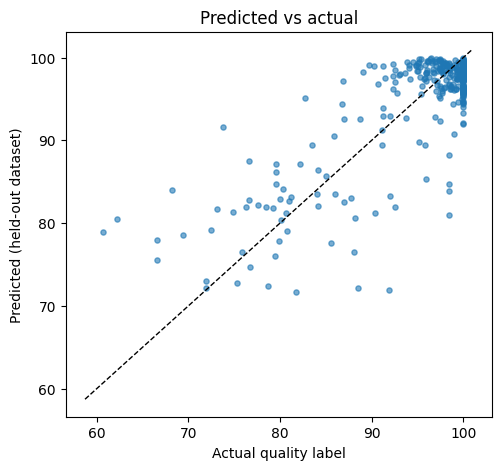

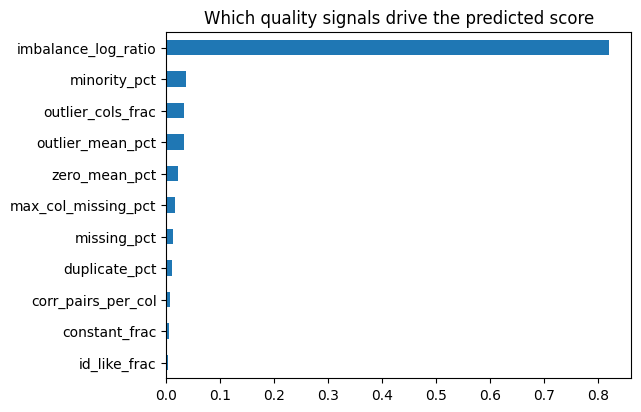

In [41]:
os.makedirs(f"{PROJECT}/models", exist_ok=True)
os.makedirs(f"{PROJECT}/figures", exist_ok=True)
sys.path.append(f"{PROJECT}/training")
import train_model
importlib.reload(train_model)
metrics = train_model.train()